# Дискретно-событийное моделирование с SimPy

Не будем ходить вокруг да около - сразу перейдём к коду модели шарика в коробке, написанному с применением библиотеки для ДСМ [SimPy](https://simpy.readthedocs.io/en/latest/):

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import simpy as sim

from matplotlib.patches import Rectangle


def ball_motion(env, bounds, r, v, traj):
    """Процесс движения шарика.
    """
    while True:
        dt, signs = calc_delay(bounds, v, r)
        # Создание и ожидание события
        yield env.timeout(dt)
        # Действия
        r += v * dt
        v *= signs
        traj.append((env.now, *r))


def calc_delay(bounds, v, r):
    # Распакуем аргументы для удобства
    (x_lb, x_rb), (y_bb, y_tb) = bounds
    x, y = r
    vx, vy = v
    # Вычисляем время (задержку):
    dtx, dty = 0., 0.
    # - в направлении оси Ox
    if vx > 0:
        dtx = (x_rb - x) / vx
    elif vx < 0:
        dtx = (x_lb - x) / vx
    # - в направление оси Oy
    if vy > 0:
        dty = (y_tb - y) / vy
    elif vy < 0:
        dty = (y_bb - y) / vy
    # Определяем, какую проекцию скорости инвертировать
    signs = [1, 1]
    signs[np.argmin((dtx, dty))] = -1
    return min(dtx, dty), signs


def plot_traj(traj, figax=None, **kw):
    if figax is None:
        fig, ax = plt.subplots()
    else:
        fig, ax = figax
    # Линии траектории
    ax.plot(traj[:, 1], traj[:, 2], **kw)
    # Начальная и конечная точки
    ax.plot(traj[0, 1], traj[0, 2],
            ls="", marker="o", c="purple")
    ax.plot(traj[-1, 1], traj[-1, 2],
            ls="", marker="x", c="purple")
    return fig, ax

In [3]:
def ball_motion(env, bounds, r, v, traj):
    """Процесс движения шарика.
    """
    while True:
        dt, signs = calc_delay(bounds, v, r)
        # Создание и ожидание события
        yield env.timeout(dt)
        # Действия
        # (обновление траектории и параметров движения)
        r += v * dt
        v *= signs
        traj.append((env.now, *r))

Функции `calc_delay(...)` и `plot_traj(...)` не изменяются.

Число столкновений: 25


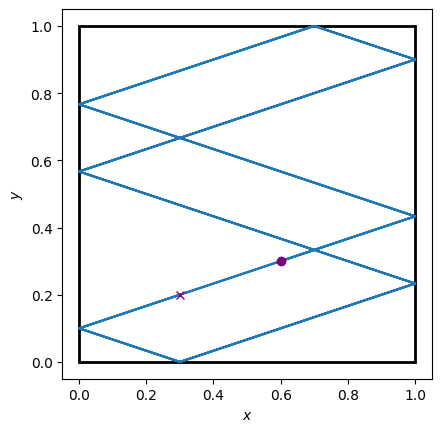

In [4]:
# Условия задачи всё те же
w, h = 1, 1
bounds = np.array([(0, w), (0, h)])
r = np.array([0.6, 0.3])
v = np.array([0.3, 0.1])
until = 59

# Моделирование (есть ли отличия?)
env = sim.Environment()
traj = [(env.now, *r)]
env.process(ball_motion(env, bounds, r, v, traj))
env.run(until)

# Обработка результатов, графики
r += v * (until - traj[-1][0])
traj.append((env.now, *r))
traj = np.array(traj)

_, ax = plot_traj(traj)
bounds_rect = Rectangle(
    bounds[:, 0], w, h,
    facecolor="none", edgecolor="k", lw=2
)
ax.add_patch(bounds_rect)
ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")
print("Число столкновений:", traj.shape[0] - 1)

plt.show()

Сравните эту программу с программой из предыдущего раздела.
Скорее всего, вы не заметите существенных различий.
И это неспроста, ведь никаких значительных отличий нет!
Разве что нам не пришлось описывать ни класс событий, ни класс среды моделирования.
Всё это (и даже больше) реализовано в SimPy.
Нам остаётся лишь описывать процессы как генераторы событий, действия в ответ на события и... всё!
Код становится максимально простым и выразительным.
Внутри SimPy крутится всё тот же цикл ДСМ: запуск процессов -> взятие ближайшего события -> обновление счётчика времени -> выполнение действий.

Более того, в SimPy реализован такой функционал, как:

* *различные типы событий*: `Event`, `Timeout` и др.;
* *завершение процесса - это тоже событие*, поэтому в качестве параметра оператора `yield` может выступать процесс (генератор событий). Процесс завершается, когда генератор заканчивается (в генераторе срабатывает оператор `return`);
* *условные события* (англ. *condition events*): `any_of(...)`, `all_of(...)`;
* *ресурсы* (англ. *resources*): `Resource`, `Container`, `Store`;
* возможность *прерывания процессов* (англ. *interruption*).

С частью этого функционала мы познакомимся ближе в следующем разделе.

## Исходный код

Число столкновений: 25


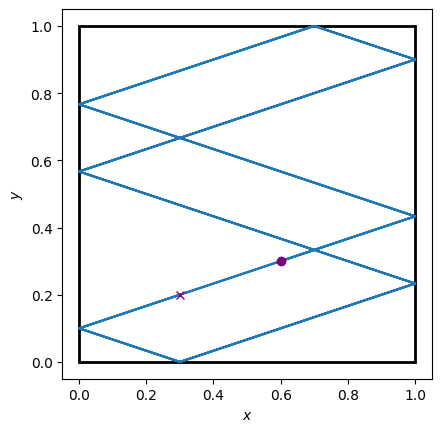

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import simpy as sim

from matplotlib.patches import Rectangle


def ball_motion(env, bounds, r, v, traj):
    """Процесс движения шарика.
    """
    while True:
        dt, signs = calc_delay(bounds, v, r)
        # Создание и ожидание события
        yield env.timeout(dt)
        # Действия
        r += v * dt
        v *= signs
        traj.append((env.now, *r))


def calc_delay(bounds, v, r):
    # Распакуем аргументы для удобства
    (x_lb, x_rb), (y_bb, y_tb) = bounds
    x, y = r
    vx, vy = v
    # Вычисляем время (задержку):
    dtx, dty = 0., 0.
    # - в направлении оси Ox
    if vx > 0:
        dtx = (x_rb - x) / vx
    elif vx < 0:
        dtx = (x_lb - x) / vx
    # - в направление оси Oy
    if vy > 0:
        dty = (y_tb - y) / vy
    elif vy < 0:
        dty = (y_bb - y) / vy
    # Определяем, какую проекцию скорости инвертировать
    signs = [1, 1]
    signs[np.argmin((dtx, dty))] = -1
    return min(dtx, dty), signs


def plot_traj(traj, figax=None, **kw):
    if figax is None:
        fig, ax = plt.subplots()
    else:
        fig, ax = figax
    # Линии траектории
    ax.plot(traj[:, 1], traj[:, 2], **kw)
    # Начальная и конечная точки
    ax.plot(traj[0, 1], traj[0, 2],
            ls="", marker="o", c="purple")
    ax.plot(traj[-1, 1], traj[-1, 2],
            ls="", marker="x", c="purple")
    return fig, ax


# Условия задачи
w, h = 1, 1
bounds = np.array([(0, w), (0, h)])
r = np.array([0.6, 0.3])
v = np.array([0.3, 0.1])
until = 59

# Моделирование
env = sim.Environment()
traj = [(env.now, *r)]
env.process(ball_motion(env, bounds, r, v, traj))
env.run(until)

# Обработка результатов, графики
r += v * (until - traj[-1][0])
traj.append((env.now, *r))
traj = np.array(traj)

_, ax = plot_traj(traj)
bounds_rect = Rectangle(
    bounds[:, 0], w, h,
    facecolor="none", edgecolor="k", lw=2
)
ax.add_patch(bounds_rect)
ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")
print("Число столкновений:", traj.shape[0] - 1)

plt.show()